# Rolling Evaluation: Full Retrain vs Incremental Fine-tuning

Compare two strategies for updating a **Johnson SU Probabilistic Transformer**
as new monthly data arrives:

| Method | Description |
|--------|-------------|
| **Full Retrain** | Build a new model from random weights each month, train on *all* available data (30 epochs) |
| **Incremental** | Keep previous weights, fine-tune on all available data with lower learning rate (10 epochs) |

**Setup:**
- Initial training period: 2 years (Feb 2023 – Jan 2025)
- Rolling evaluation: 12 monthly windows (Feb 2025 – Jan 2026)
- Model: `ProbabilisticTransformer` with `JohnsonSUHead`

In [1]:
import os
import sys
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

current_dir = Path.cwd()
project_root = str(current_dir) if (current_dir / 'config.py').exists() else str(current_dir.parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from config import DataConfig, ExperimentConfig, ModelConfig, TrainingConfig
from models import ProbabilisticTransformer
from core.experiment_utils import CANONICAL_MODEL_CONFIG, CANONICAL_TRAIN_CONFIG, set_seeds
from core.evaluator import Evaluator
from transformations import StandardScalingTransformation
from data.loader import DataLoader

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

try:
    gpus = tf.config.experimental.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs: {len(gpus)}")
except Exception:
    pass

2026-03-10 09:57:27.805382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773133047.959196    9235 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773133048.001488    9235 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773133048.328192    9235 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773133048.328244    9235 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773133048.328252    9235 computation_placer.cc:177] computation placer alr

GPUs: 1


In [2]:
INPUT_WINDOW = 168
OUTPUT_HORIZON = 24
TRAIN_START = pd.Timestamp("2023-02-01")
INITIAL_TRAIN_END = pd.Timestamp("2025-02-01")

RETRAIN_EPOCHS = 30
RETRAIN_LR = 7e-4
RETRAIN_PATIENCE = 5

FINETUNE_EPOCHS = 10
FINETUNE_LR = 1e-4
FINETUNE_PATIENCE = 3

RESULTS_DIR = Path(project_root) / "results" / "rolling_evaluation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Full retrain :", f"{RETRAIN_EPOCHS} epochs, LR={RETRAIN_LR}, patience={RETRAIN_PATIENCE}")
print("Fine-tune    :", f"{FINETUNE_EPOCHS} epochs, LR={FINETUNE_LR}, patience={FINETUNE_PATIENCE}")

Full retrain : 30 epochs, LR=0.0007, patience=5
Fine-tune    : 10 epochs, LR=0.0001, patience=3


In [3]:
loader = DataLoader(DataConfig())
prices, exog = loader.load_raw_data()
df_full = prices.to_frame(name="Prices")
if exog is not None:
    df_full = df_full.join(exog)
df_full.index = pd.to_datetime(df_full.index)
df_full = df_full.sort_index()

month_starts = pd.date_range(INITIAL_TRAIN_END, periods=13, freq="MS")
n_windows = len(month_starts) - 1

print(f"Dataset : {df_full.index[0]} → {df_full.index[-1]}  ({len(df_full):,} rows, {df_full.shape[1]} features)")
print(f"\nRolling schedule ({n_windows} months):")
for i in range(n_windows):
    n_tr = len(df_full[(df_full.index >= TRAIN_START) & (df_full.index < month_starts[i])])
    n_te = len(df_full[(df_full.index >= month_starts[i]) & (df_full.index < month_starts[i + 1])])
    print(f"  {i+1:2d}. Train → {month_starts[i].strftime('%Y-%m-%d')}, "
          f"predict {month_starts[i].strftime('%b %Y'):>8s}  "
          f"({n_tr:,} train / {n_te:,} test hours)")

Dataset : 2023-02-01 00:00:00 → 2026-01-31 23:00:00  (26,304 rows, 28 features)

Rolling schedule (12 months):
   1. Train → 2025-02-01, predict Feb 2025  (17,544 train / 672 test hours)
   2. Train → 2025-03-01, predict Mar 2025  (18,216 train / 744 test hours)
   3. Train → 2025-04-01, predict Apr 2025  (18,960 train / 720 test hours)
   4. Train → 2025-05-01, predict May 2025  (19,680 train / 744 test hours)
   5. Train → 2025-06-01, predict Jun 2025  (20,424 train / 720 test hours)
   6. Train → 2025-07-01, predict Jul 2025  (21,144 train / 744 test hours)
   7. Train → 2025-08-01, predict Aug 2025  (21,888 train / 744 test hours)
   8. Train → 2025-09-01, predict Sep 2025  (22,632 train / 720 test hours)
   9. Train → 2025-10-01, predict Oct 2025  (23,352 train / 744 test hours)
  10. Train → 2025-11-01, predict Nov 2025  (24,096 train / 720 test hours)
  11. Train → 2025-12-01, predict Dec 2025  (24,816 train / 744 test hours)
  12. Train → 2026-01-01, predict Jan 2026  (25,560 t

In [4]:
def create_sequences(data_values, input_window, output_horizon):
    n_seq = len(data_values) - input_window - output_horizon + 1
    if n_seq <= 0:
        return np.empty((0, input_window, data_values.shape[1])), np.empty((0, output_horizon))
    X, y = [], []
    for i in range(n_seq):
        w = data_values[i : i + input_window]
        t = data_values[i + input_window : i + input_window + output_horizon, 0]
        if not (np.isnan(w).any() or np.isnan(t).any()):
            X.append(w)
            y.append(t)
    return np.array(X), np.array(y)


def prepare_window(train_end, test_end):
    """Prepare scaled train / val / test arrays and a fresh scaler for one rolling window."""
    train_all = df_full[(df_full.index >= TRAIN_START) & (df_full.index < train_end)]
    val_n = int(len(train_all) * 0.1)
    train_df = train_all.iloc[:-val_n]
    val_df = train_all.iloc[-val_n:]

    ctx_start = train_end - pd.Timedelta(hours=INPUT_WINDOW)
    test_df = df_full[(df_full.index >= ctx_start) & (df_full.index < test_end)]

    X_tr, y_tr = create_sequences(train_df.values, INPUT_WINDOW, OUTPUT_HORIZON)
    X_va, y_va = create_sequences(val_df.values, INPUT_WINDOW, OUTPUT_HORIZON)
    X_te, y_te = create_sequences(test_df.values, INPUT_WINDOW, OUTPUT_HORIZON)

    scaler = StandardScalingTransformation()
    scaler.fit(X_tr, y_tr)
    X_tr_s, y_tr_s = scaler.transform(X_tr, y_tr)
    X_va_s, y_va_s = scaler.transform(X_va, y_va)
    X_te_s, _ = scaler.transform(X_te, y_te)

    return X_tr_s, y_tr_s, X_va_s, y_va_s, X_te_s, y_te, scaler, X_tr.shape[-1]


def build_model(n_features, lr):
    """Build a fresh ProbabilisticTransformer with Johnson SU head."""
    conf = ExperimentConfig(
        name="rolling",
        data_config=DataConfig(input_window=INPUT_WINDOW, output_horizon=OUTPUT_HORIZON),
        model_config=ModelConfig(**CANONICAL_MODEL_CONFIG),
        training_config=TrainingConfig(learning_rate=lr),
        head_type="johnson_su",
    )
    m = ProbabilisticTransformer(conf)
    m.build_model(n_features)
    return m


def fit_model(model, X_tr, y_tr, X_va, y_va, epochs, patience, lr=None):
    """Train or fine-tune a model. Recompiles with *lr* when provided. Returns wall-clock seconds."""
    if lr is not None:
        model.keras_model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss=lambda yt, yp: model.head.loss(yt, yp),
        )
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=patience, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=max(patience - 1, 2), min_lr=1e-7
        ),
    ]
    t0 = time.time()
    model.keras_model.fit(
        X_tr, y_tr,
        epochs=epochs,
        batch_size=32,
        validation_data=(X_va, y_va),
        callbacks=callbacks,
        verbose=0,
    )
    return time.time() - t0


def evaluate_window(model, scaler, X_te_s, y_te):
    """Evaluate on one test window. Returns (metrics_dict, y_pred_original)."""
    evaluator = Evaluator(model, scaler)
    metrics = evaluator.evaluate(X_te_s, y_te)
    y_pred = evaluator.generate_forecasts(X_te_s)
    return metrics, y_pred


print("Helpers ready.")

Helpers ready.


---
## Method 1 — Full Retrain

For every monthly window the model is **built from scratch** (random weight
initialisation) and trained for up to 30 epochs on the entire expanding
training set.  This is the gold-standard approach but also the most expensive.

In [5]:
print("=" * 70)
print("  METHOD 1: FULL RETRAIN FROM SCRATCH")
print("=" * 70)

results_retrain = []

for w in range(n_windows):
    train_end = month_starts[w]
    test_end = month_starts[w + 1]
    label = train_end.strftime("%b %Y")

    print(f"\n--- Window {w + 1}/{n_windows}: {label} ---")

    X_tr, y_tr, X_va, y_va, X_te, y_te, scaler, n_feat = prepare_window(train_end, test_end)
    print(f"  sequences  train={X_tr.shape[0]:,}  val={X_va.shape[0]:,}  test={X_te.shape[0]:,}")

    tf.keras.backend.clear_session()
    gc.collect()
    set_seeds(w)

    model = build_model(n_feat, RETRAIN_LR)
    t = fit_model(model, X_tr, y_tr, X_va, y_va, RETRAIN_EPOCHS, RETRAIN_PATIENCE)
    metrics, y_pred = evaluate_window(model, scaler, X_te, y_te)
    metrics["training_time"] = t

    results_retrain.append({"month": label, **metrics})
    print(f"  MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}  "
          f"CRPS={metrics['CRPS']:.4f}  PICP={metrics['PICP']:.3f}  time={t:.1f}s")

del model
gc.collect()
tf.keras.backend.clear_session()

print("\nDone — full retrain.")

  METHOD 1: FULL RETRAIN FROM SCRATCH

--- Window 1/12: Feb 2025 ---
  sequences  train=7,850  val=552  test=649


I0000 00:00:1773133053.487428    9235 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7483 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080, pci bus id: 0000:01:00.0, compute capability: 6.1
I0000 00:00:1773133060.136912    9330 service.cc:152] XLA service 0x734cf8004c00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773133060.136928    9330 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1080, Compute Capability 6.1
2026-03-10 09:57:40.369629: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773133061.450405    9330 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1773133069.361471    9330 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  MAE=21.7928  RMSE=28.4509  CRPS=15.9914  PICP=0.930  time=68.1s

--- Window 2/12: Mar 2025 ---
  sequences  train=7,850  val=1,224  test=530
  MAE=22.6971  RMSE=30.8279  CRPS=17.1376  PICP=0.858  time=75.2s

--- Window 3/12: Apr 2025 ---
  sequences  train=7,922  val=1,514  test=697
  MAE=29.3968  RMSE=42.4636  CRPS=22.2905  PICP=0.892  time=69.4s

--- Window 4/12: May 2025 ---
  sequences  train=8,570  val=1,586  test=721
  MAE=32.7346  RMSE=49.8478  CRPS=25.0893  PICP=0.786  time=82.2s

--- Window 5/12: Jun 2025 ---
  sequences  train=9,217  val=1,851  test=697
  MAE=30.3407  RMSE=40.3890  CRPS=23.8936  PICP=0.804  time=85.4s

--- Window 6/12: Jul 2025 ---
  sequences  train=9,697  val=1,923  test=721
  MAE=21.1087  RMSE=34.7536  CRPS=15.6062  PICP=0.911  time=97.2s

--- Window 7/12: Aug 2025 ---
  sequences  train=10,367  val=1,997  test=721
  MAE=17.7326  RMSE=23.7546  CRPS=12.7484  PICP=0.926  time=125.1s

--- Window 8/12: Sep 2025 ---
  sequences  train=11,036  val=2,072  test=

2026-03-10 10:23:20.852969: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_transpose_fusion_5', 8 bytes spill stores, 8 bytes spill loads



  MAE=22.1157  RMSE=28.7191  CRPS=15.6759  PICP=0.873  time=105.6s

--- Window 11/12: Dec 2025 ---
  sequences  train=13,002  val=1,954  test=721
  MAE=15.3845  RMSE=20.0330  CRPS=11.1386  PICP=0.861  time=122.4s

--- Window 12/12: Jan 2026 ---
  sequences  train=13,671  val=2,042  test=553
  MAE=16.0725  RMSE=20.9073  CRPS=11.3916  PICP=0.986  time=101.7s

Done — full retrain.


---
## Method 2 — Incremental Fine-tuning

The model is trained **once** on the initial 2-year window (same settings as
Method 1).  For every subsequent month, the existing weights are kept and the
model is **fine-tuned** on the full expanding training set with a lower
learning rate (1e-4) and fewer epochs (10).

The key savings come from:
1. Starting from pre-trained weights (faster convergence)
2. Fewer training epochs per update
3. No model rebuild overhead

In [6]:
print("=" * 70)
print("  METHOD 2: INCREMENTAL FINE-TUNING")
print("=" * 70)

results_finetune = []
inc_model = None

for w in range(n_windows):
    train_end = month_starts[w]
    test_end = month_starts[w + 1]
    label = train_end.strftime("%b %Y")

    print(f"\n--- Window {w + 1}/{n_windows}: {label} ---")

    X_tr, y_tr, X_va, y_va, X_te, y_te, scaler, n_feat = prepare_window(train_end, test_end)
    print(f"  sequences  train={X_tr.shape[0]:,}  val={X_va.shape[0]:,}  test={X_te.shape[0]:,}")

    if w == 0:
        tf.keras.backend.clear_session()
        gc.collect()
        set_seeds(0)
        inc_model = build_model(n_feat, RETRAIN_LR)
        t = fit_model(inc_model, X_tr, y_tr, X_va, y_va, RETRAIN_EPOCHS, RETRAIN_PATIENCE)
        mode = "initial"
    else:
        t = fit_model(inc_model, X_tr, y_tr, X_va, y_va,
                       FINETUNE_EPOCHS, FINETUNE_PATIENCE, lr=FINETUNE_LR)
        mode = "fine-tune"

    metrics, y_pred = evaluate_window(inc_model, scaler, X_te, y_te)
    metrics["training_time"] = t

    results_finetune.append({"month": label, **metrics})
    print(f"  [{mode:>9s}] MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}  "
          f"CRPS={metrics['CRPS']:.4f}  PICP={metrics['PICP']:.3f}  time={t:.1f}s")

del inc_model
gc.collect()
tf.keras.backend.clear_session()

print("\nDone — incremental fine-tuning.")

  METHOD 2: INCREMENTAL FINE-TUNING

--- Window 1/12: Feb 2025 ---
  sequences  train=7,850  val=552  test=649
  [  initial] MAE=19.5389  RMSE=25.3330  CRPS=14.5079  PICP=0.799  time=88.8s

--- Window 2/12: Mar 2025 ---
  sequences  train=7,850  val=1,224  test=530
  [fine-tune] MAE=23.2301  RMSE=30.6707  CRPS=18.4927  PICP=0.628  time=53.0s

--- Window 3/12: Apr 2025 ---
  sequences  train=7,922  val=1,514  test=697
  [fine-tune] MAE=24.4489  RMSE=35.1866  CRPS=19.8201  PICP=0.633  time=55.1s

--- Window 4/12: May 2025 ---
  sequences  train=8,570  val=1,586  test=721
  [fine-tune] MAE=31.7468  RMSE=46.4147  CRPS=25.9923  PICP=0.496  time=56.9s

--- Window 5/12: Jun 2025 ---
  sequences  train=9,217  val=1,851  test=697
  [fine-tune] MAE=26.5813  RMSE=35.0019  CRPS=21.7743  PICP=0.607  time=66.8s

--- Window 6/12: Jul 2025 ---
  sequences  train=9,697  val=1,923  test=721
  [fine-tune] MAE=19.5413  RMSE=31.8468  CRPS=15.0408  PICP=0.797  time=70.2s

--- Window 7/12: Aug 2025 ---
  seq

2026-03-10 10:54:23.098793: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_transpose_fusion_5', 8 bytes spill stores, 8 bytes spill loads



  [fine-tune] MAE=20.1713  RMSE=26.3816  CRPS=15.2738  PICP=0.709  time=70.1s

--- Window 11/12: Dec 2025 ---
  sequences  train=13,002  val=1,954  test=721
  [fine-tune] MAE=16.3221  RMSE=21.3900  CRPS=12.6142  PICP=0.663  time=85.1s

--- Window 12/12: Jan 2026 ---
  sequences  train=13,671  val=2,042  test=553
  [fine-tune] MAE=16.6407  RMSE=22.0698  CRPS=12.1939  PICP=0.762  time=75.2s

Done — incremental fine-tuning.


---
## Comparison

In [7]:
df_rt = pd.DataFrame(results_retrain)
df_ft = pd.DataFrame(results_finetune)

compare = pd.DataFrame({
    "Month": df_rt["month"],
    "MAE (retrain)": df_rt["MAE"].values,
    "MAE (incr.)": df_ft["MAE"].values,
    "\u0394MAE": df_ft["MAE"].values - df_rt["MAE"].values,
    "CRPS (retrain)": df_rt["CRPS"].values,
    "CRPS (incr.)": df_ft["CRPS"].values,
    "\u0394CRPS": df_ft["CRPS"].values - df_rt["CRPS"].values,
    "Time retrain (s)": df_rt["training_time"].values,
    "Time incr. (s)": df_ft["training_time"].values,
    "Speedup": df_rt["training_time"].values / df_ft["training_time"].values,
})
display(compare.style.format(precision=4).set_caption("Per-month comparison"))

,Month,MAE (retrain),MAE (incr.),ΔMAE,CRPS (retrain),CRPS (incr.),ΔCRPS,Time retrain (s),Time incr. (s),Speedup
0,Feb 2025,21.7928,19.5389,-2.2539,15.9914,14.5079,-1.4835,68.1435,88.8309,0.7671
1,Mar 2025,22.6971,23.2301,0.5330,17.1376,18.4927,1.3551,75.2386,52.9647,1.4205
2,Apr 2025,29.3968,24.4489,-4.9480,22.2905,19.8201,-2.4705,69.3556,55.0570,1.2597
3,May 2025,32.7346,31.7468,-0.9878,25.0893,25.9923,0.9030,82.1707,56.8858,1.4445
4,Jun 2025,30.3407,26.5813,-3.7594,23.8936,21.7743,-2.1193,85.3517,66.8139,1.2775
5,Jul 2025,21.1087,19.5413,-1.5675,15.6062,15.0408,-0.5654,97.1943,70.2281,1.3840
6,Aug 2025,17.7326,18.7987,1.0661,12.7484,14.0298,1.2813,125.0569,64.4815,1.9394
7,Sep 2025,26.5552,28.8104,2.2551,19.8823,22.8094,2.9271,98.9019,66.7384,1.4819
8,Oct 2025,23.1535,23.9860,0.8325,16.7780,18.4503,1.6722,112.8768,67.2701,1.6780
9,Nov 2025,22.1157,20.1713,-1.9444,15.6759,15.2738,-0.4021,105.6439,70.1272,1.5065


In [8]:
key = ["MAE", "RMSE", "CRPS", "PICP", "training_time"]
summary = pd.DataFrame({
    "Metric": key,
    "Retrain mean": [df_rt[m].mean() for m in key],
    "Retrain std": [df_rt[m].std() for m in key],
    "Incr. mean": [df_ft[m].mean() for m in key],
    "Incr. std": [df_ft[m].std() for m in key],
})
display(summary.style.format(precision=4).set_caption("Aggregate statistics across 12 months"))

total_rt = df_rt["training_time"].sum()
total_ft = df_ft["training_time"].sum()
print(f"Total training time:")
print(f"  Full retrain : {total_rt:8.1f}s  ({total_rt / 60:.1f} min)")
print(f"  Incremental  : {total_ft:8.1f}s  ({total_ft / 60:.1f} min)")
print(f"  Speedup      : {total_rt / total_ft:.2f}x")

,Metric,Retrain mean,Retrain std,Incr. mean,Incr. std
0,MAE,23.2571,5.5684,22.4847,4.8398
1,RMSE,32.0841,8.9123,30.7247,7.2380
2,CRPS,17.3020,4.6400,17.5833,4.3671
3,PICP,0.8840,0.0557,0.6937,0.0972
4,training_time,95.3310,19.4827,68.3019,10.9451


Total training time:
  Full retrain :   1144.0s  (19.1 min)
  Incremental  :    819.6s  (13.7 min)
  Speedup      : 1.40x


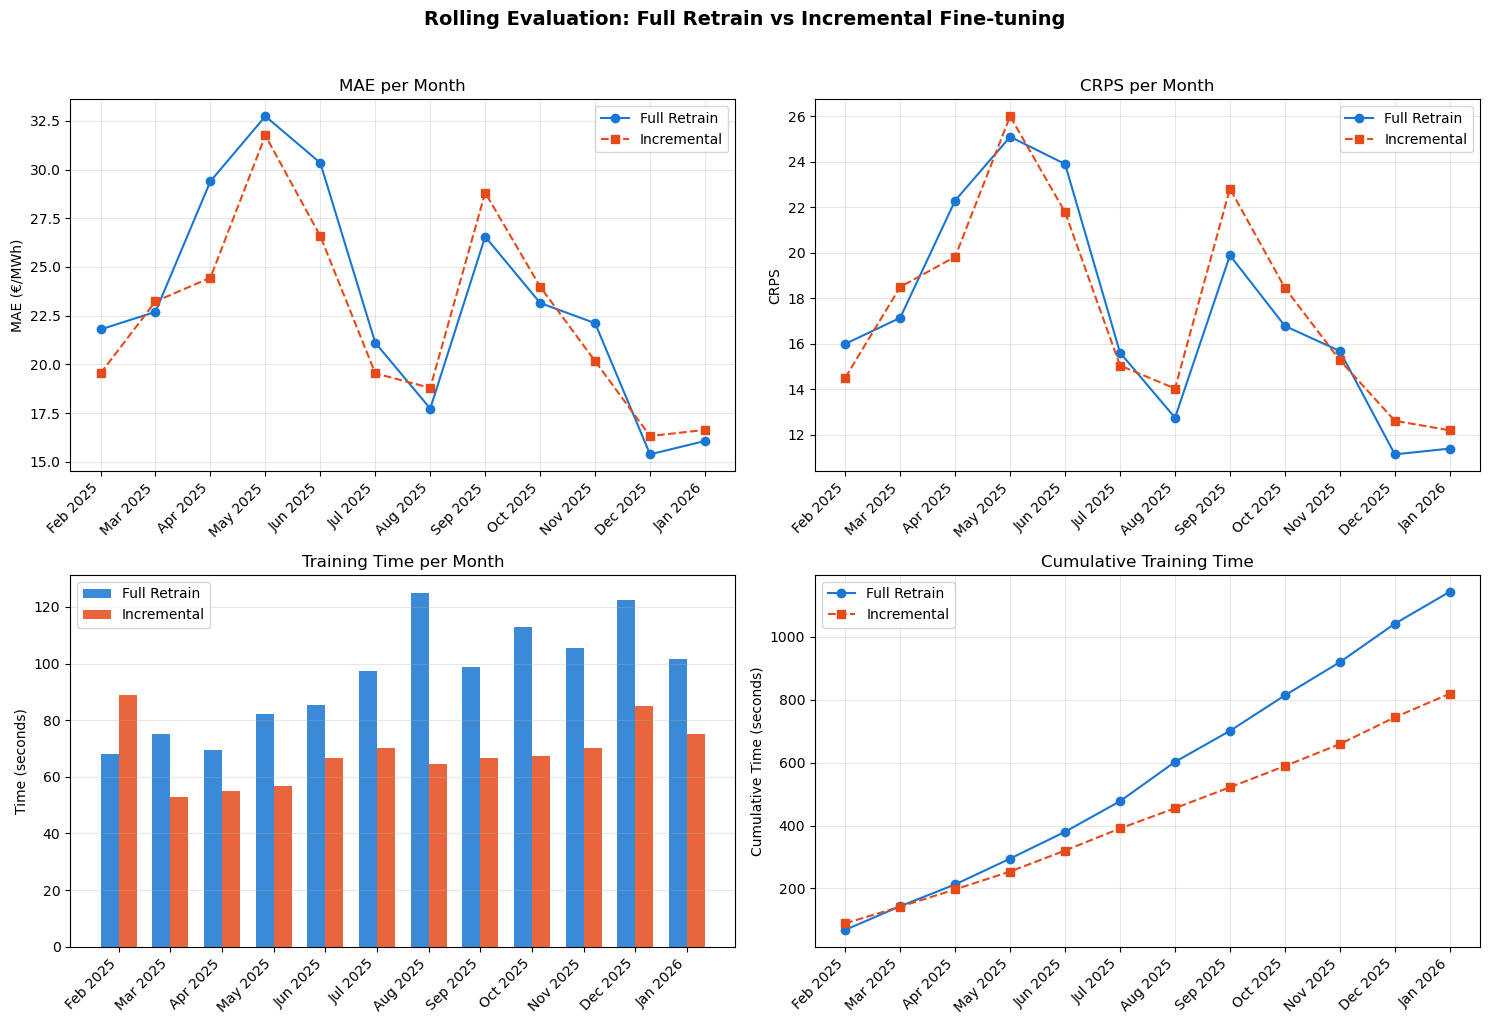

In [9]:
months = df_rt["month"]
x = np.arange(len(months))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1 — MAE per month
ax = axes[0, 0]
ax.plot(x, df_rt["MAE"], "o-", label="Full Retrain", color="#1976D2")
ax.plot(x, df_ft["MAE"], "s--", label="Incremental", color="#E64A19")
ax.set_ylabel("MAE (\u20ac/MWh)")
ax.set_title("MAE per Month")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)

# 2 — CRPS per month
ax = axes[0, 1]
ax.plot(x, df_rt["CRPS"], "o-", label="Full Retrain", color="#1976D2")
ax.plot(x, df_ft["CRPS"], "s--", label="Incremental", color="#E64A19")
ax.set_ylabel("CRPS")
ax.set_title("CRPS per Month")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)

# 3 — Training time per month
ax = axes[1, 0]
w = 0.35
ax.bar(x - w / 2, df_rt["training_time"], w, label="Full Retrain", color="#1976D2", alpha=0.85)
ax.bar(x + w / 2, df_ft["training_time"], w, label="Incremental", color="#E64A19", alpha=0.85)
ax.set_ylabel("Time (seconds)")
ax.set_title("Training Time per Month")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# 4 — Cumulative training time
ax = axes[1, 1]
ax.plot(x, df_rt["training_time"].cumsum(), "o-", label="Full Retrain", color="#1976D2")
ax.plot(x, df_ft["training_time"].cumsum(), "s--", label="Incremental", color="#E64A19")
ax.set_ylabel("Cumulative Time (seconds)")
ax.set_title("Cumulative Training Time")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Rolling Evaluation: Full Retrain vs Incremental Fine-tuning",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "rolling_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

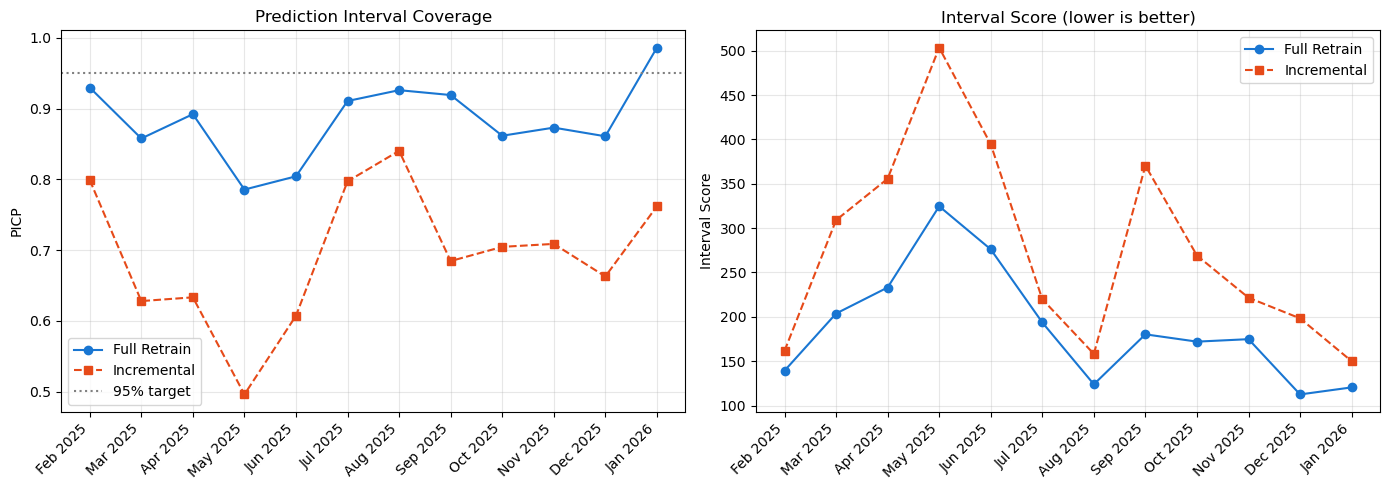

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(x, df_rt["PICP"], "o-", label="Full Retrain", color="#1976D2")
ax.plot(x, df_ft["PICP"], "s--", label="Incremental", color="#E64A19")
ax.axhline(0.95, ls=":", color="gray", label="95% target")
ax.set_ylabel("PICP")
ax.set_title("Prediction Interval Coverage")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x, df_rt["IntervalScore"], "o-", label="Full Retrain", color="#1976D2")
ax.plot(x, df_ft["IntervalScore"], "s--", label="Incremental", color="#E64A19")
ax.set_ylabel("Interval Score")
ax.set_title("Interval Score (lower is better)")
ax.set_xticks(x)
ax.set_xticklabels(months, rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "rolling_interval_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
df_rt.to_csv(RESULTS_DIR / "results_full_retrain.csv", index=False)
df_ft.to_csv(RESULTS_DIR / "results_incremental.csv", index=False)
print(f"Results saved to {RESULTS_DIR}")

Results saved to /home/d1ff1cult/masterproef_new/results/rolling_evaluation
